# DEAI-opdracht: Lineaire Regressie op Ames Housing

In deze notebook lees ik de dataset uit **AmesHousing.xlsx** in, bepaal ik de **targetvariabele**, kies ik een eerste set features, voer ik **one-hot encoding** uit voor categorische features, split ik de data in **X_train, X_test, y_train en y_test**, train ik een **lineair regressiemodel** en vergelijk ik meerdere experimenten.

> Op basis van de opdracht is de targetvariabele **SalePrice** en moet minstens één gekozen feature categorisch zijn. Daarom start ik met:
>
> - **Overall Qual**
> - **Gr Liv Area**
> - **Neighborhood** *(categorisch)*


In [1]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import inspect


In [2]:
# 1. Dataset inlezen
excel_path = "AmesHousing.xlsx"
df = pd.read_excel(excel_path, sheet_name="AmesHousing")
data_dictionary = pd.read_excel(excel_path, sheet_name="Data Dictionary")

print(f"Vorm van de dataset: {df.shape}")
display(df.head())

Vorm van de dataset: (2930, 12)


,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story


In [3]:

# 2. Data Dictionary bekijken
display(data_dictionary)

print("Kolommen in de dataset:")
print(df.columns.tolist())


,Variabele,Betekenis
0,ID,"Uniek nummer per huis, te vergelijken met een ..."
1,SalePrice,Verkoopprijs van het huis (in dollars: USD)
2,Garage,Geeft weer of het huis wel/geen garage bevat
3,Overall Qual,Algemene kwaliteit van materialen en afwerking...
4,Gr Liv Area,Woonoppervlak boven de grond (square feet)
5,Total Bsmt SF,Totale oppervlakte van de kelder
6,Lot Area,Grootte van het perceel (square feet)
7,Year Built,Bouwjaar van het huis
8,Full Bath,Aantal volledige badkamers
9,Bedroom AbvGr,Aantal slaapkamers boven de grond


Kolommen in de dataset:
['ID', 'SalePrice', 'Garage', 'Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Lot Area', 'Year Built', 'Full Bath', 'Bedroom AbvGr', 'Neighborhood', 'House Style']


## Targetvariabele en verwachte top 3 features

De targetvariabele is **SalePrice**.  
Mijn eerste verwachting voor de meest voorspellende features:

1. **Overall Qual** – de algemene kwaliteit van materialen en afwerking
2. **Gr Liv Area** – het woonoppervlak boven de grond
3. **Neighborhood** – de wijk, dus een belangrijke locatie-indicator *(categorisch)*

Ik laat **ID** buiten beschouwing, omdat dit alleen een uniek nummer per huis is en geen inhoudelijke woningeigenschap.


In [4]:

target = "SalePrice"
initial_features = ["Overall Qual", "Gr Liv Area", "Neighborhood"]
initial_categorical = ["Neighborhood"]

print("Target:", target)
print("Initiële features:", initial_features)
print("Categorische feature(s):", initial_categorical)


Target: SalePrice
Initiële features: ['Overall Qual', 'Gr Liv Area', 'Neighborhood']
Categorische feature(s): ['Neighborhood']


## One-hot encoding (voorbeeld)

Hieronder laat ik eerst expliciet zien hoe one-hot encoding werkt op de initiële featureset.
Daarna gebruik ik in de echte modeltraining een pipeline, zodat de encoding netjes alleen op de trainingsdata wordt geleerd.


In [5]:

encoded_preview = pd.get_dummies(df[initial_features], columns=initial_categorical, dtype=int)
print("Aantal kolommen vóór encoding:", len(initial_features))
print("Aantal kolommen ná encoding:", encoded_preview.shape[1])
display(encoded_preview.head())


Aantal kolommen vóór encoding: 3
Aantal kolommen ná encoding: 30


,Overall Qual,Gr Liv Area,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,6,1656,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5,896,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,1329,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,7,2110,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,1629,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Data splitsen: horizontaal én verticaal

- **Horizontaal**: onafhankelijke variabelen (**X**) en afhankelijke variabele (**y**) scheiden
- **Verticaal**: train- en testset maken

Zo ontstaan de vier gevraagde stukken:
- `X_train`
- `X_test`
- `y_train`
- `y_test`


In [6]:

X = df[initial_features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (2490, 3)
X_test : (440, 3)
y_train: (2490,)
y_test : (440,)


## Hyperparameters onderzoeken

De opdracht vraagt om hyperparameters te onderzoeken met `help()`.

In een echte werksessie kun je bijvoorbeeld dit gebruiken:

```python
help(SGDRegressor)
```

Ik kies hier bewust voor **SGDRegressor** als lineair regressiemodel, omdat dit model hyperparameters heeft zoals:
- `max_iter`  → vergelijkbaar met het aantal epochs
- `eta0`      → initiële learning rate
- `learning_rate`
- `penalty`


In [7]:

print("Signatuur van SGDRegressor:")
print(inspect.signature(SGDRegressor))


Signatuur van SGDRegressor:
(loss='squared_error', *, penalty='l2', alpha=0.0001, l1_ratio=0.15, fit_intercept=True, max_iter=1000, tol=0.001, shuffle=True, verbose=0, epsilon=0.1, random_state=None, learning_rate='invscaling', eta0=0.01, power_t=0.25, early_stopping=False, validation_fraction=0.1, n_iter_no_change=5, warm_start=False, average=False)


In [8]:

def train_and_evaluate(features, categorical_features, max_iter=1000, eta0=0.01,
                       learning_rate="constant", penalty="l2", alpha=0.0001,
                       random_state=42):
    X = df[features].copy()
    y = df[target].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.15, random_state=random_state
    )

    numeric_features = [col for col in features if col not in categorical_features]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_features)
        ]
    )

    model = SGDRegressor(
        max_iter=max_iter,
        eta0=eta0,
        learning_rate=learning_rate,
        penalty=penalty,
        alpha=alpha,
        random_state=random_state
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    return {
        "features": features,
        "categorical_features": categorical_features,
        "max_iter": max_iter,
        "eta0": eta0,
        "learning_rate": learning_rate,
        "penalty": penalty,
        "alpha": alpha,
        "X_train_shape": X_train.shape,
        "X_test_shape": X_test.shape,
        "y_train_shape": y_train.shape,
        "y_test_shape": y_test.shape,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "pipeline": pipeline,
        "y_test": y_test,
        "predictions": predictions
    }


## Initiële run

In [9]:

initial_run = train_and_evaluate(
    features=["Overall Qual", "Gr Liv Area", "Neighborhood"],
    categorical_features=["Neighborhood"],
    max_iter=1000,
    eta0=0.01,
    learning_rate="constant",
    penalty="l2",
    alpha=0.0001
)

initial_metrics = pd.DataFrame([{
    "MSE": initial_run["MSE"],
    "RMSE": initial_run["RMSE"],
    "MAE": initial_run["MAE"],
    "R2": initial_run["R2"]
}]).round(4)

print("Vier stukken na split:")
print("X_train:", initial_run["X_train_shape"])
print("X_test :", initial_run["X_test_shape"])
print("y_train:", initial_run["y_train_shape"])
print("y_test :", initial_run["y_test_shape"])
display(initial_metrics)


Vier stukken na split:
X_train: (2490, 3)
X_test : (440, 3)
y_train: (2490,)
y_test : (440,)


,MSE,RMSE,MAE,R2
0,1.499674e+09,38725.6208,25014.787,0.8048


## Experimenten

Ik voer meerdere experimenten uit om te zien of het model beter kan presteren dan de initiële run.

### Logica achter de experimenten
- Eerst voeg ik **meer inhoudelijke features** toe
- Daarna test ik of **nog meer features** helpen
- Vervolgens zie ik dat de prestaties met alle 10 bruikbare features en dezelfde learning rate verslechteren
- Daarom experimenteer ik daarna met:
  - een **lagere learning rate**
  - een **adaptive learning rate**
  - een **ander aantal epochs** (`max_iter`)


In [10]:

experiment_configs = [
    {
        "run": "Initieel",
        "reden": "Startmodel met 3 verwachte topfeatures",
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood"],
        "categorical": ["Neighborhood"],
        "max_iter": 1000,
        "eta0": 0.01,
        "learning_rate": "constant",
        "penalty": "l2",
        "alpha": 0.0001
    },
    {
        "run": "Exp1",
        "reden": "House Style toegevoegd als extra categorische feature",
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood", "House Style"],
        "categorical": ["Neighborhood", "House Style"],
        "max_iter": 1000,
        "eta0": 0.01,
        "learning_rate": "constant",
        "penalty": "l2",
        "alpha": 0.0001
    },
    {
        "run": "Exp2",
        "reden": "Total Bsmt SF en Garage toegevoegd",
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood", "House Style", "Total Bsmt SF", "Garage"],
        "categorical": ["Neighborhood", "House Style", "Garage"],
        "max_iter": 1000,
        "eta0": 0.01,
        "learning_rate": "constant",
        "penalty": "l2",
        "alpha": 0.0001
    },
    {
        "run": "Exp3",
        "reden": "Alle 10 bruikbare features, maar nog dezelfde learning rate",
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood", "House Style", "Total Bsmt SF", "Garage", "Lot Area", "Year Built", "Full Bath", "Bedroom AbvGr"],
        "categorical": ["Neighborhood", "House Style", "Garage"],
        "max_iter": 1000,
        "eta0": 0.01,
        "learning_rate": "constant",
        "penalty": "l2",
        "alpha": 0.0001
    },
    {
        "run": "Exp4",
        "reden": "Zelfde 10 features, maar lagere learning rate",
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood", "House Style", "Total Bsmt SF", "Garage", "Lot Area", "Year Built", "Full Bath", "Bedroom AbvGr"],
        "categorical": ["Neighborhood", "House Style", "Garage"],
        "max_iter": 1000,
        "eta0": 0.001,
        "learning_rate": "constant",
        "penalty": "l2",
        "alpha": 0.0001
    },
    {
        "run": "Exp5",
        "reden": "Adaptive learning rate, maar weinig epochs",
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood", "House Style", "Total Bsmt SF", "Garage", "Lot Area", "Year Built", "Full Bath", "Bedroom AbvGr"],
        "categorical": ["Neighborhood", "House Style", "Garage"],
        "max_iter": 20,
        "eta0": 0.01,
        "learning_rate": "adaptive",
        "penalty": "l2",
        "alpha": 0.0001
    },
    {
        "run": "Exp6",
        "reden": "Adaptive learning rate én meer epochs",
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood", "House Style", "Total Bsmt SF", "Garage", "Lot Area", "Year Built", "Full Bath", "Bedroom AbvGr"],
        "categorical": ["Neighborhood", "House Style", "Garage"],
        "max_iter": 200,
        "eta0": 0.01,
        "learning_rate": "adaptive",
        "penalty": "l2",
        "alpha": 0.0001
    }
]

experiment_results = []
all_runs = {}

for config in experiment_configs:
    result = train_and_evaluate(
        features=config["features"],
        categorical_features=config["categorical"],
        max_iter=config["max_iter"],
        eta0=config["eta0"],
        learning_rate=config["learning_rate"],
        penalty=config["penalty"],
        alpha=config["alpha"]
    )

    all_runs[config["run"]] = result

    experiment_results.append({
        "Run": config["run"],
        "Reden": config["reden"],
        "Aantal features": len(config["features"]),
        "Features": ", ".join(config["features"]),
        "Categorisch": ", ".join(config["categorical"]),
        "max_iter": config["max_iter"],
        "eta0": config["eta0"],
        "learning_rate": config["learning_rate"],
        "penalty": config["penalty"],
        "MSE": result["MSE"],
        "RMSE": result["RMSE"],
        "MAE": result["MAE"],
        "R2": result["R2"]
    })

results_df = pd.DataFrame(experiment_results)
results_df_rounded = results_df.copy()
for col in ["MSE", "RMSE", "MAE", "R2"]:
    results_df_rounded[col] = results_df_rounded[col].round(4)

display(results_df_rounded)


,Run,Reden,Aantal features,Features,Categorisch,max_iter,eta0,learning_rate,penalty,MSE,RMSE,MAE,R2
0,Initieel,Startmodel met 3 verwachte topfeatures,3,"Overall Qual, Gr Liv Area, Neighborhood",Neighborhood,1000,0.010,constant,l2,1.499674e+09,38725.6208,25014.7870,0.8048
1,Exp1,House Style toegevoegd als extra categorische ...,4,"Overall Qual, Gr Liv Area, Neighborhood, House...","Neighborhood, House Style",1000,0.010,constant,l2,1.397753e+09,37386.5321,23201.5760,0.8181
2,Exp2,Total Bsmt SF en Garage toegevoegd,6,"Overall Qual, Gr Liv Area, Neighborhood, House...","Neighborhood, House Style, Garage",1000,0.010,constant,l2,1.328185e+09,36444.2701,22025.9992,0.8271
3,Exp3,"Alle 10 bruikbare features, maar nog dezelfde ...",10,"Overall Qual, Gr Liv Area, Neighborhood, House...","Neighborhood, House Style, Garage",1000,0.010,constant,l2,1.600761e+09,40009.5068,25443.3216,0.7916
4,Exp4,"Zelfde 10 features, maar lagere learning rate",10,"Overall Qual, Gr Liv Area, Neighborhood, House...","Neighborhood, House Style, Garage",1000,0.001,constant,l2,1.264689e+09,35562.4691,21754.4928,0.8354
5,Exp5,"Adaptive learning rate, maar weinig epochs",10,"Overall Qual, Gr Liv Area, Neighborhood, House...","Neighborhood, House Style, Garage",20,0.010,adaptive,l2,1.251767e+09,35380.3187,22052.5634,0.8371
6,Exp6,Adaptive learning rate én meer epochs,10,"Overall Qual, Gr Liv Area, Neighborhood, House...","Neighborhood, House Style, Garage",200,0.010,adaptive,l2,1.240001e+09,35213.6482,21385.5200,0.8386


In [11]:

# Experimenten sorteren op hoogste R2-score
display(results_df.sort_values("R2", ascending=False)[["Run", "Aantal features", "max_iter", "eta0", "learning_rate", "RMSE", "MAE", "R2"]].round(4))


,Run,Aantal features,max_iter,eta0,learning_rate,RMSE,MAE,R2
6,Exp6,10,200,0.010,adaptive,35213.6482,21385.5200,0.8386
5,Exp5,10,20,0.010,adaptive,35380.3187,22052.5634,0.8371
4,Exp4,10,1000,0.001,constant,35562.4691,21754.4928,0.8354
2,Exp2,6,1000,0.010,constant,36444.2701,22025.9992,0.8271
1,Exp1,4,1000,0.010,constant,37386.5321,23201.5760,0.8181
0,Initieel,3,1000,0.010,constant,38725.6208,25014.7870,0.8048
3,Exp3,10,1000,0.010,constant,40009.5068,25443.3216,0.7916


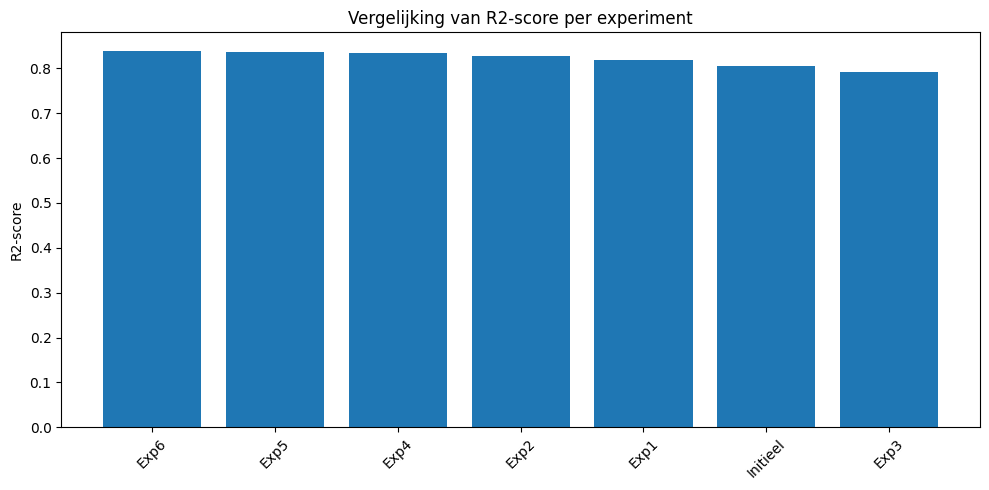

In [12]:

# Visuele vergelijking van R2 per experiment
plot_df = results_df.sort_values("R2", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["Run"], plot_df["R2"])
plt.ylabel("R2-score")
plt.title("Vergelijking van R2-score per experiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Beste model bekijken

In [13]:

best_row = results_df.sort_values("R2", ascending=False).iloc[0]
best_run_name = best_row["Run"]
best_result = all_runs[best_run_name]

print("Beste run:", best_run_name)
print(best_row[["Aantal features", "max_iter", "eta0", "learning_rate", "penalty", "RMSE", "MAE", "R2"]].round(4))


Beste run: Exp6


TypeError: type str doesn't define __round__ method

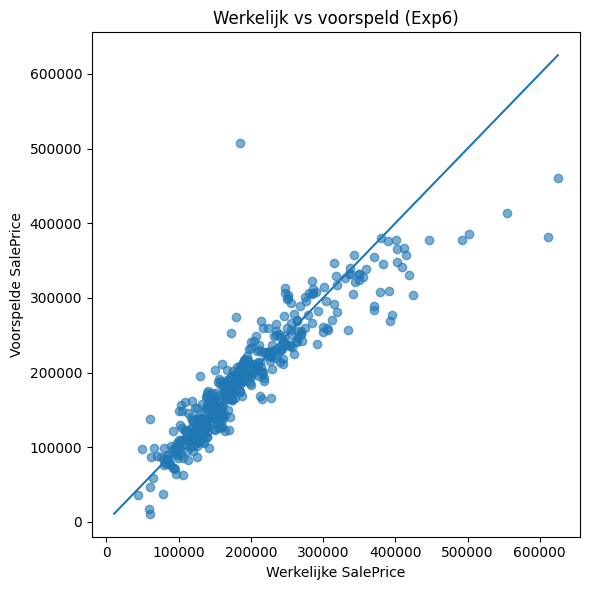

In [14]:

# Scatterplot: werkelijke vs voorspelde verkoopprijs voor het beste model
y_test_best = best_result["y_test"]
pred_best = best_result["predictions"]

plt.figure(figsize=(6, 6))
plt.scatter(y_test_best, pred_best, alpha=0.6)
min_val = min(y_test_best.min(), pred_best.min())
max_val = max(y_test_best.max(), pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.xlabel("Werkelijke SalePrice")
plt.ylabel("Voorspelde SalePrice")
plt.title(f"Werkelijk vs voorspeld ({best_run_name})")
plt.tight_layout()
plt.show()


## Conclusie

- De **initiële run** met 3 features presteerde al redelijk goed.
- Het toevoegen van **House Style**, daarna **Total Bsmt SF** en **Garage**, verbeterde het model verder.
- Toen ik **alle 10 bruikbare features** toevoegde met dezelfde learning rate, werd het model juist slechter.
- Dat inspireerde een nieuw experiment met een **lagere learning rate** en daarna met een **adaptive learning rate**.
- De beste configuratie werd uiteindelijk:

**Exp6**
- Features: 10 bruikbare features
- Categorische features: `Neighborhood`, `House Style`, `Garage`
- `max_iter = 200`
- `eta0 = 0.01`
- `learning_rate = "adaptive"`
- `penalty = "l2"`

Daarmee werd de **R2-score hoger** en de **RMSE / MAE lager** dan in de initiële run.
